In [1]:
# SVM CODE

from sklearn.svm import SVC
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, auc

In [2]:
data = {
    "Hours_Studied": [2, 3, 5, 7, 8, 10],
    "CGPA": [5.5, 6.0, 7.0, 8.0, 8.5, 9.0],
    "Placed": [0, 0, 0, 1, 1, 1]  
}
df = pd.DataFrame(data)
df


,Hours_Studied,CGPA,Placed
0,2,5.5,0
1,3,6.0,0
2,5,7.0,0
3,7,8.0,1
4,8,8.5,1
5,10,9.0,1


In [3]:
X = df[["Hours_Studied", "CGPA"]]
y = df["Placed"]
X
y

0    0
1    0
2    0
3    1
4    1
5    1
Name: Placed, dtype: int64

In [4]:
model = SVC(kernel='linear')
model.fit(X, y)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [5]:
y_pred = model.predict(X)
y_pred

array([0, 0, 0, 1, 1, 1])

In [6]:
new_points = np.array([[4, 6.5], [9, 8.8]])
new_preds = model.predict(new_points)
new_preds

C:\Users\Pratyaya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([0, 1])

In [7]:
print(f"Accuracy Score: {accuracy_score(y, y_pred)}")
print(f"Precision: {precision_score(y, y_pred)}")
print(f"Recall: {recall_score(y, y_pred)}")
print(f"F1 Score: {f1_score(y, y_pred)}")


Accuracy Score: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [8]:
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))
print("\nClassification Report:\n", classification_report(y, y_pred))

Confusion Matrix:
 [[3 0]
 [0 3]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [9]:
w = model.coef_[0]
b = model.intercept_[0]

print("\nWeight (w):", w)
print("Bias (b):", b)


Weight (w): [0.8 0.4]
Bias (b): -7.800000000000001


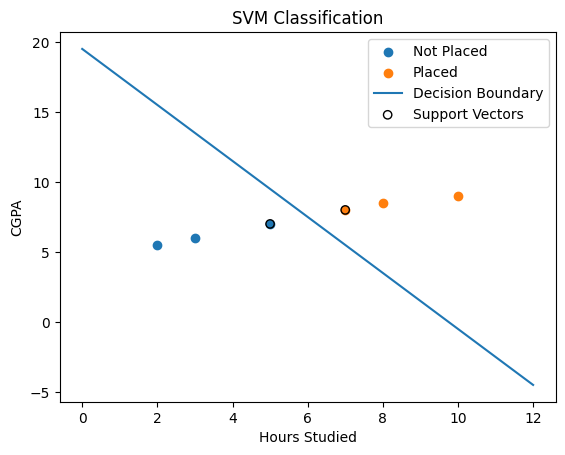

In [10]:
plt.scatter(X[y==0]["Hours_Studied"], X[y==0]["CGPA"], label="Not Placed")
plt.scatter(X[y==1]["Hours_Studied"], X[y==1]["CGPA"], label="Placed")
x_values = np.linspace(0, 12, 100)
y_values = -(w[0]*x_values + b) / w[1]
plt.plot(x_values, y_values, label="Decision Boundary")
sv = model.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], facecolors='none', edgecolors='black', label="Support Vectors")
plt.xlabel("Hours Studied")
plt.ylabel("CGPA")
plt.title("SVM Classification")
plt.legend()
plt.show()